C:\Users\melco\AppData\Local\Temp\ipykernel_23604\1127812923.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_30_septiembre ['T_acumulado_min'] = df_30_septiembre ['Diferencia_minutos'].cumsum()
C:\Users\melco\AppData\Local\Temp\ipykernel_23604\1127812923.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_01_octubre ['T_acumulado_min'] = df_01_octubre ['Diferencia_minutos'].cumsum()


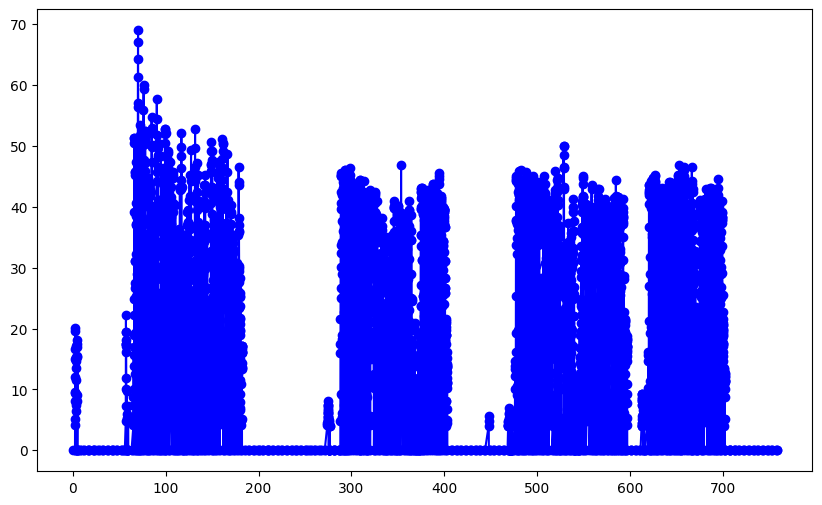

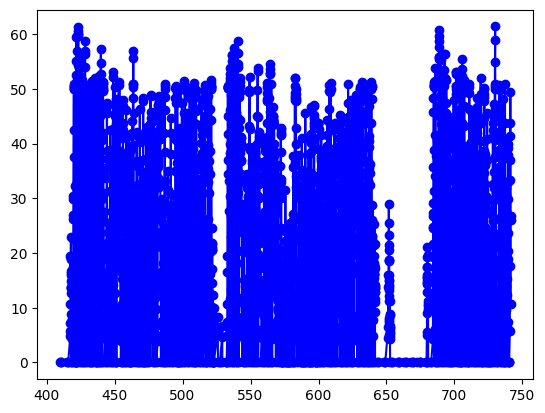

                  Tiempo  Velocidad   Latitud   Longitud  T_acumulado_min
0    2024-09-30 10:16:48        0.0 -0.340268 -78.549055         0.000000
1    2024-09-30 10:19:23        0.0 -0.340268 -78.549055         2.583333
2    2024-09-30 10:19:24        0.0 -0.340268 -78.549055         2.600000
3    2024-09-30 10:19:25        8.1 -0.340338 -78.549015         2.616667
4    2024-09-30 10:19:27        9.4 -0.340306 -78.548981         2.650000
...                  ...        ...       ...        ...              ...
5246 2024-09-30 22:49:30        0.0 -0.339100 -78.548786       752.700000
5247 2024-09-30 22:49:31        0.0 -0.339100 -78.548786       752.716667
5248 2024-09-30 22:53:31        0.0 -0.339100 -78.548786       756.716667
5249 2024-09-30 22:54:34        0.0 -0.339100 -78.548786       757.766667
5250 2024-09-30 22:54:35        0.0 -0.339100 -78.548786       757.783333

[5251 rows x 5 columns]
Número de viajes detectados: 54


In [66]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import os
import matplotlib.pyplot as plt

# Constante de la Tierra
R = 6373.0

# Función Haversine Vectorizada
def haversine_vector(lat1, lon1, lat2, lon2):
    # Convertir las coordenadas a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c * 1000  # Distancia en metros
    return distance

# Supongamos que ya tienes el DataFrame cargado con las columnas 'Latitud' y 'Longitud'
# Ejemplo de DataFrame (reemplaza esto con la lectura de tu archivo CSV)
df=pd.read_excel("C:/Users/melco/OneDrive/Escritorio/pasantia_imple/visualstudio/datos.xlsx")

# Usamos shift para obtener las columnas anteriores de latitud y longitud
#df['Latitud_anterior'] = df['Latitud'].shift()
#df['Longitud_anterior'] = df['Longitud'].shift()

# Calculamos las distancias de manera vectorizada, omitiendo las primeras filas donde no hay datos previos
#df['Distancia'] = haversine_vector(df['Latitud_anterior'], df['Longitud_anterior'], df['Latitud'], df['Longitud'])

# Llenamos los valores NaN de la primera fila con 0 (porque no tienen fila anterior para comparar)
#df['Distancia'].fillna(0, inplace=True)

df = df[['Tiempo','Velocidad', 'Latitud','Longitud']]


# Convertir la columna 'Tiempo' a datetime
df['Tiempo'] = pd.to_datetime(df['Tiempo'])

df['Diferencia_minutos'] = df['Tiempo'].diff().dt.total_seconds() / 60
df['Diferencia_minutos'] = df['Diferencia_minutos'].fillna(0)


# Convertir la columna 'Velocidad' a numérico, removiendo 'km/h' y convirtiendo a float
df['Velocidad'] = df['Velocidad'].str.replace(' km/h', '').astype(float)
df['Velocidad_0'] = df['Velocidad'] == 0

# Acumular el tiempo cuando la velocidad es 0
df['Tiempo_acum_0'] = df['Tiempo_diff'].where(df['Velocidad_0']).cumsum()

# Reiniciar el acumulador cuando la velocidad no es 0
df['Tiempo_acum_0'] = df['Tiempo_acum_0'].where(df['Velocidad_0'], 0)

# Crear un grupo donde la velocidad permanece en 0 por más de 10 minutos
df['split_group'] = (df['Tiempo_acum_0'] >= 10).cumsum()

# Crear una lista de dataframes separados
dataframes = [group for _, group in df.groupby((df['split_group']).shift().fillna(0).astype(int))]

# Remover las columnas temporales innecesarias
for df_part in dataframes:
    df_part.drop(columns=['Velocidad_0', 'Tiempo_diff', 'Tiempo_acum_0', 'split_group'], inplace=True)

# Obtener el directorio actual
directorio_actual = os.getcwd()

df_30_septiembre = df[df['Tiempo'].dt.date == pd.to_datetime('2024-09-30').date()]
df_01_octubre = df[df['Tiempo'].dt.date == pd.to_datetime('2024-10-01').date()]


df_30_septiembre ['T_acumulado_min'] = df_30_septiembre ['Diferencia_minutos'].cumsum()
df_01_octubre ['T_acumulado_min'] = df_01_octubre ['Diferencia_minutos'].cumsum()

df_30_septiembre = df_30_septiembre[['Tiempo','Velocidad',  'Latitud','Longitud','T_acumulado_min']]
df_01_octubre = df_01_octubre[['Tiempo','Velocidad',  'Latitud','Longitud','T_acumulado_min']]
plt.figure(figsize=(10, 6))
plt.plot(df_30_septiembre ['T_acumulado_min'], df_30_septiembre ['Velocidad'], marker='o', linestyle='-', color='b')
plt.show()
plt.plot(df_01_octubre ['T_acumulado_min'], df_01_octubre ['Velocidad'], marker='o', linestyle='-', color='b')
plt.show()

print(df_30_septiembre)

df_30_septiembre.to_csv('df_30_septiembre.csv', index=False)
df_01_octubre.to_csv('df_01_octubre.csv', index=False)

# Agrupar por fecha y guardar cada grupo en un archivo CSV separado
#for fecha, grupo in df.groupby(df['Tiempo'].dt.date):
#    fecha_formateada = fecha.strftime('%Y%m%d')
#    nombre_archivo = f'{fecha_formateada}.csv'
#    ruta_archivo = os.path.join(directorio_actual, nombre_archivo)
#    grupo.to_csv(ruta_archivo, index=False)
#    print(f"Archivo guardado: {nombre_archivo}")

# Crear una nueva columna 'Fecha' solo con la fecha
#df['Fecha'] = df['Tiempo'].dt.date

# Crear una nueva columna 'Hora' solo con el tiempo
#df['Hora'] = df['Tiempo'].dt.time

# Filtrar los datos por cada fecha
#df_30_septiembre = df[df['Fecha'] == pd.to_datetime('2024-09-30').date()]
#df_01_octubre = df[df['Fecha'] == pd.to_datetime('2024-10-01').date()]

#df_30_septiembre = df_30_septiembre[['Tiempo','Velocidad',  'Latitud','Longitud']]
#df_01_octubre = df_01_octubre[['Tiempo','Velocidad',  'Latitud','Longitud']]

# Definir el umbral de velocidad para considerar una pausa
umbral_velocidad = 5  # Por ejemplo, menos de 5 km/h indica una pausa
tiempo_pausa = 180 # Número de filas que indican una pausa prolongada entre viajes

# Crear una columna que marque las pausas
df_30_septiembre['Pausa'] = np.where(df_30_septiembre['Velocidad'] < umbral_velocidad, 1, 0)

df_30_septiembre['Diferencia_tiempo'] = df_30_septiembre['Tiempo'].diff().dt.total_seconds()
df_30_septiembre['Nuevo_viaje'] = ((df_30_septiembre['Pausa'] == 1) & (df_30_septiembre['Diferencia_tiempo'] > tiempo_pausa)).cumsum()

# Separar los viajes en DataFrames individuales
viajes = [df_30_septiembre[df_30_septiembre['Nuevo_viaje'] == viaje].reset_index(drop=True) for viaje in df_30_septiembre['Nuevo_viaje'].unique()]

# Mostrar el número de viajes detectados
print(f"Número de viajes detectados: {len(viajes)}")

# Si quieres guardar cada viaje en un archivo CSV individual
for i, viaje in enumerate(viajes):
    viaje.to_csv(f'viaje_30_sep_{i+1}.csv', index=False)






In [4]:
import pandas as pd
df=pd.read_csv("C:/Users/melco/OneDrive/Escritorio/pasantia_imple/visualstudio/df_30_septiembre.csv")
df

,Tiempo,Velocidad,Latitud,Longitud,T_acumulado_min
0,2024-09-30 10:16:48,0.0,-0.340268,-78.549055,0.000000
1,2024-09-30 10:19:23,0.0,-0.340268,-78.549055,2.583333
2,2024-09-30 10:19:24,0.0,-0.340268,-78.549055,2.600000
3,2024-09-30 10:19:25,8.1,-0.340338,-78.549015,2.616667
4,2024-09-30 10:19:27,9.4,-0.340306,-78.548981,2.650000
...,...,...,...,...,...
5246,2024-09-30 22:49:30,0.0,-0.339100,-78.548786,752.700000
5247,2024-09-30 22:49:31,0.0,-0.339100,-78.548786,752.716667
5248,2024-09-30 22:53:31,0.0,-0.339100,-78.548786,756.716667
5249,2024-09-30 22:54:34,0.0,-0.339100,-78.548786,757.766667
